# Credit Card Customer Segmentation

# Problem Statement

### Context
AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help

 

### Objective
To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

 

### Data Description
The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

### Data Dictionary
Sl_No: Primary key of the records

Customer Key: Customer identification number

Average Credit Limit: Average credit limit of each customer for all credit cards

Total credit cards: Total number of credit cards possessed by the customer

Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

Total visits online: Total number of visits or online logins made by the customer (yearly)

Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

### Importing necessary libraries

In [133]:
# this will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA


In [134]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [135]:
# load the dataset
data = pd.read_excel("Credit Card Customer Data.xlsx")

### Overview of the Dataset
The initial steps to get an overview of any dataset is to:

- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

In [136]:
# check the shape of the dataset
data.shape

(660, 7)

The dataset has 229 rows and 22 columns

### Displaying few rows of the dataset

In [137]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


In [138]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


### Create a copy of the original dataset

In [139]:
df = data.copy()

### Checking the data types of the columns

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [141]:
df.isnull().sum()   

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

### Statistical Summary of the Dataset

In [142]:
# Let's look at the statistical summary of the data
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


# Exploratory Data Analysis

### Univariate Analysis

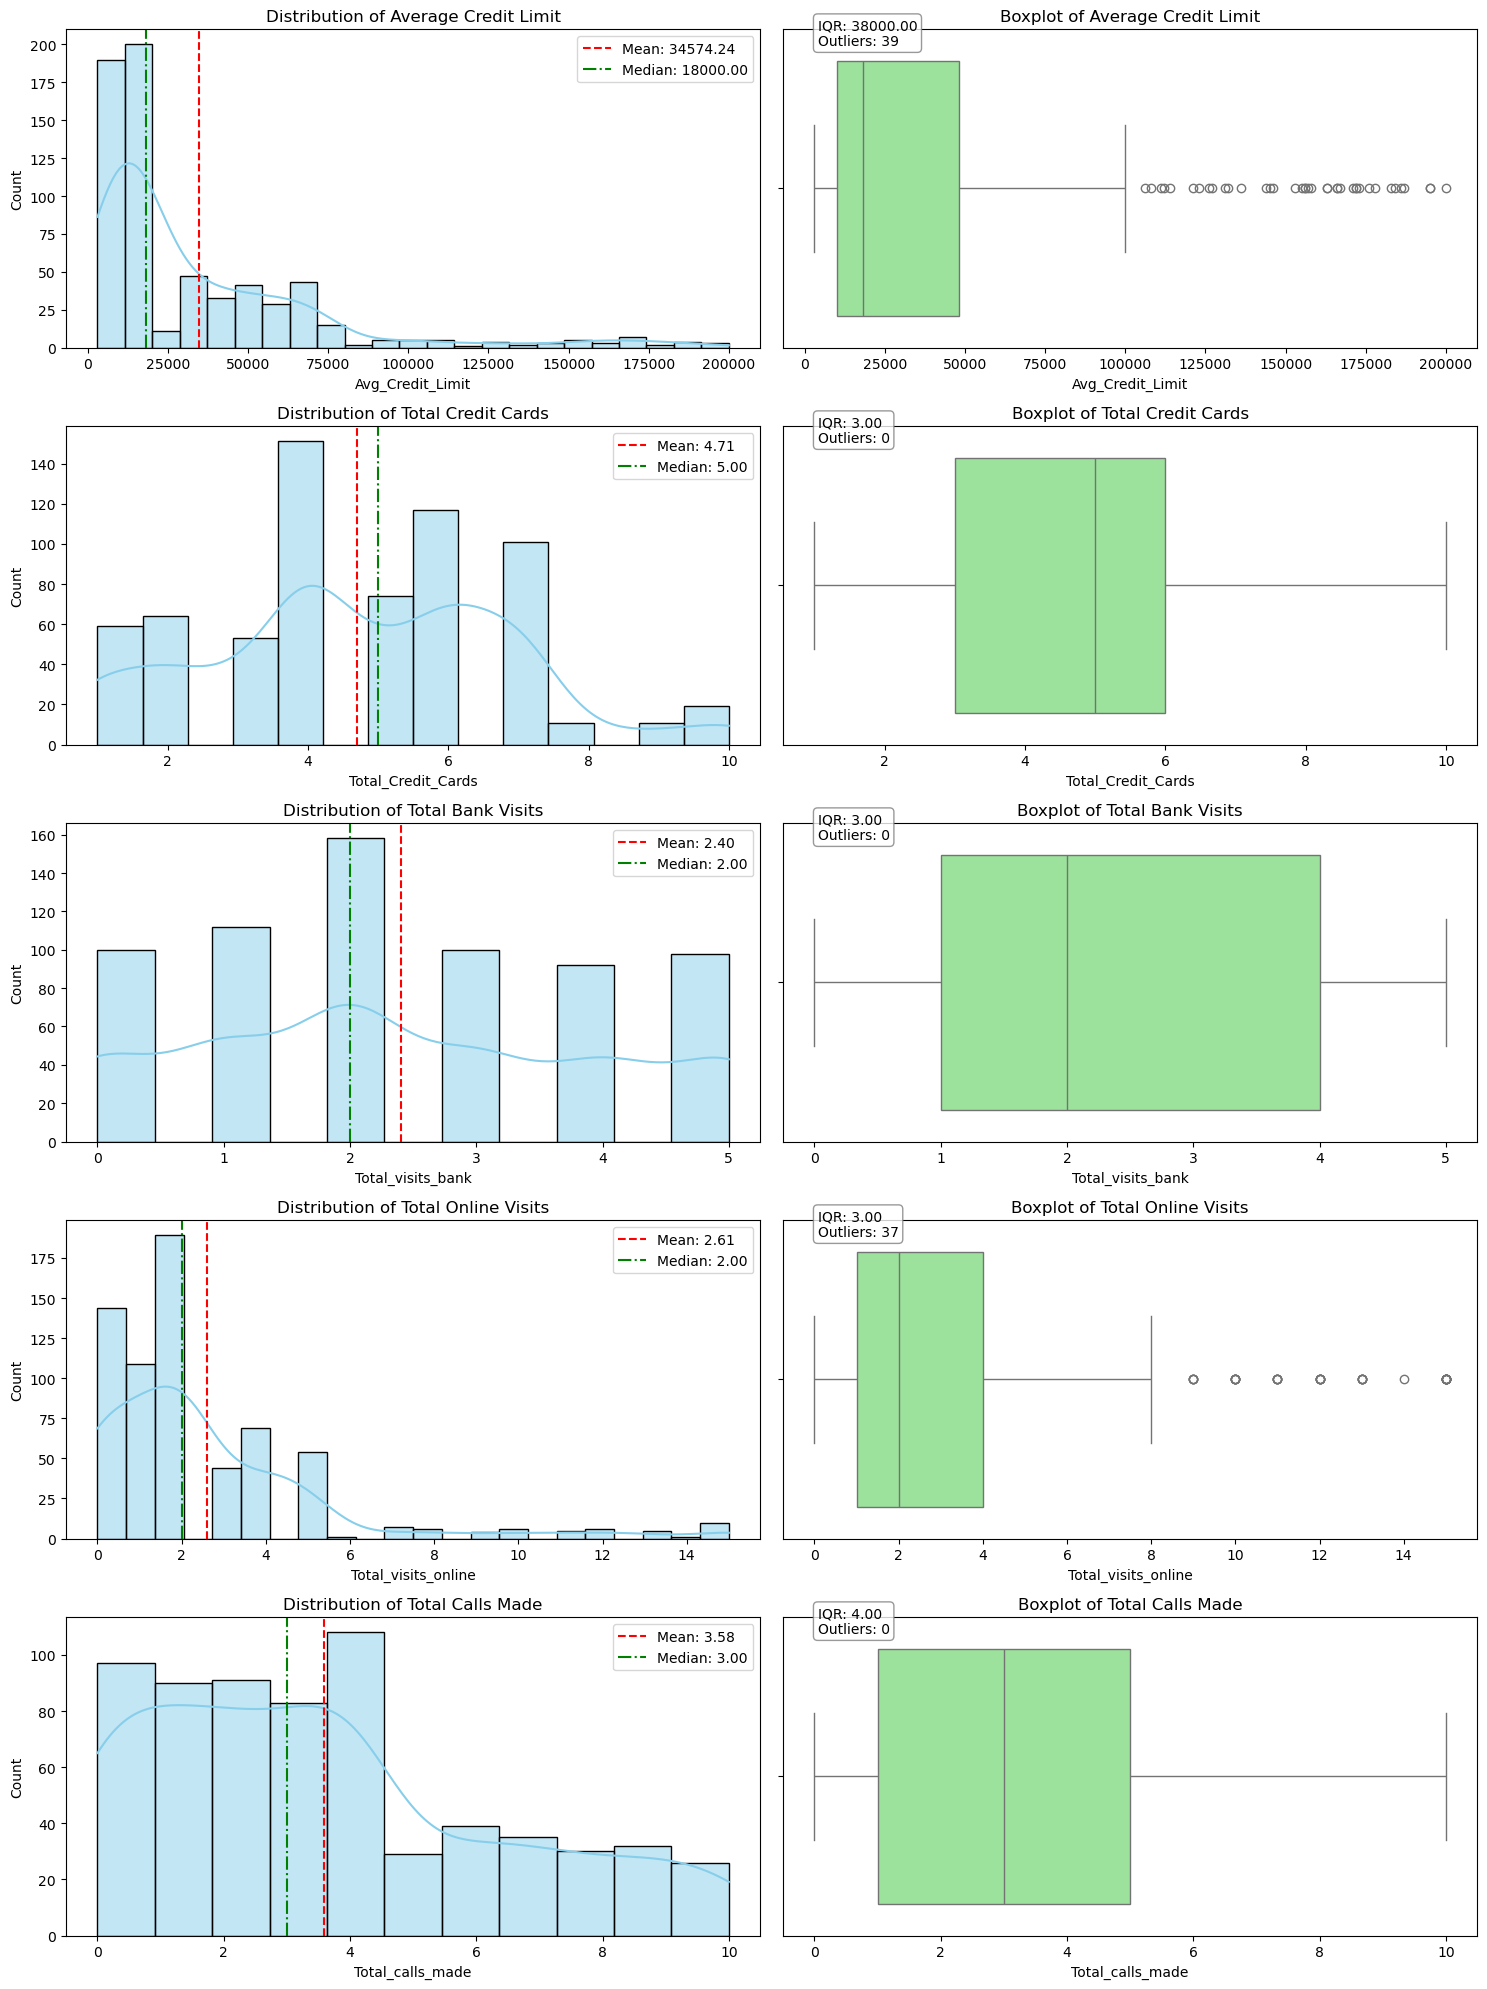

In [143]:
# Set up the figure
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 4*len(numeric_cols)))

# Create histplots and boxplots for each numeric column
for i, col in enumerate(numeric_cols):
    # Histogram with KDE on the left
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {column_display_names[col]}')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='-.', label=f'Median: {df[col].median():.2f}')
    axes[i, 0].legend()
    
    # Boxplot on the right
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {column_display_names[col]}')
    
    # Add stats annotation to boxplot
    q1, median, q3 = df[col].quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    axes[i, 1].annotate(f"IQR: {iqr:.2f}\nOutliers: {sum((df[col] < (q1-1.5*iqr)) | (df[col] > (q3+1.5*iqr)))}", 
                      xy=(0.05, 0.95), xycoords='axes fraction',
                      bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

### Bivariate Analysis

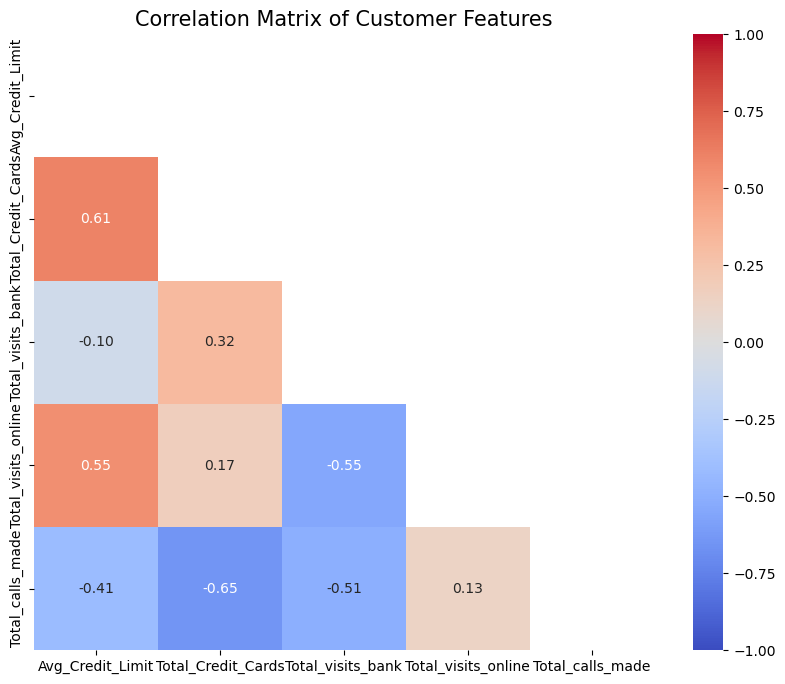

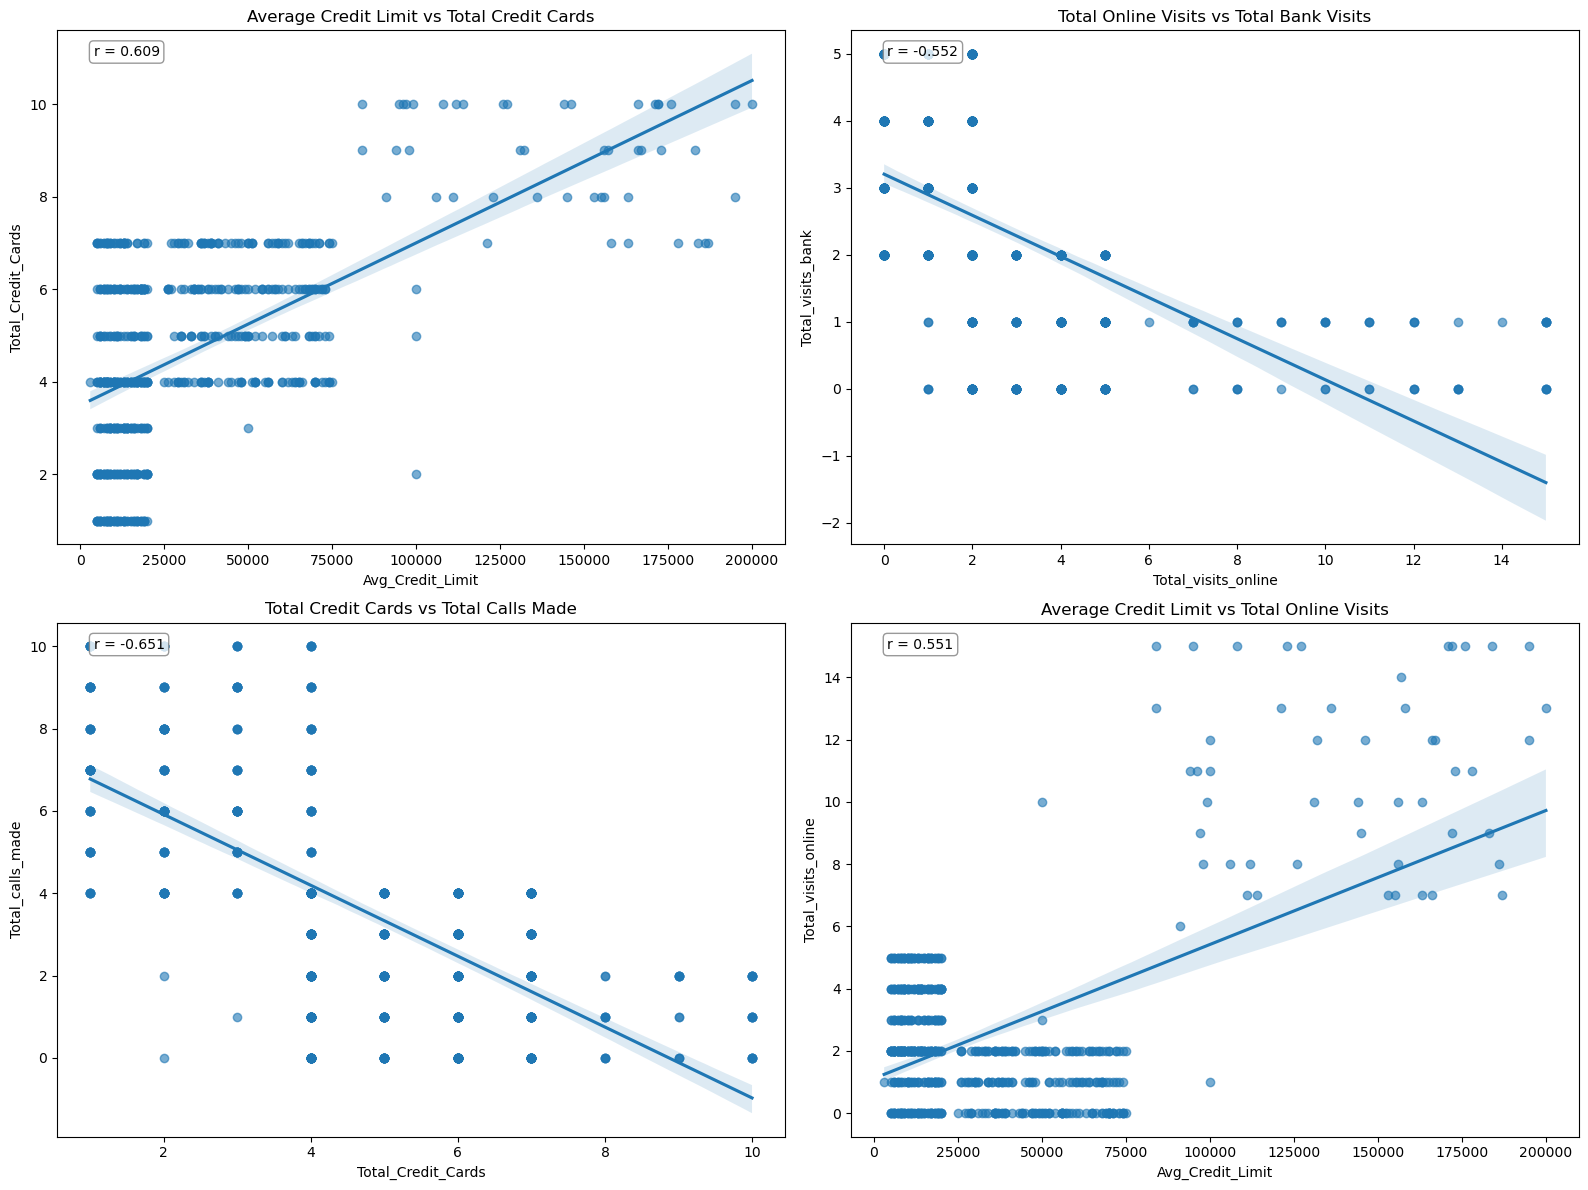

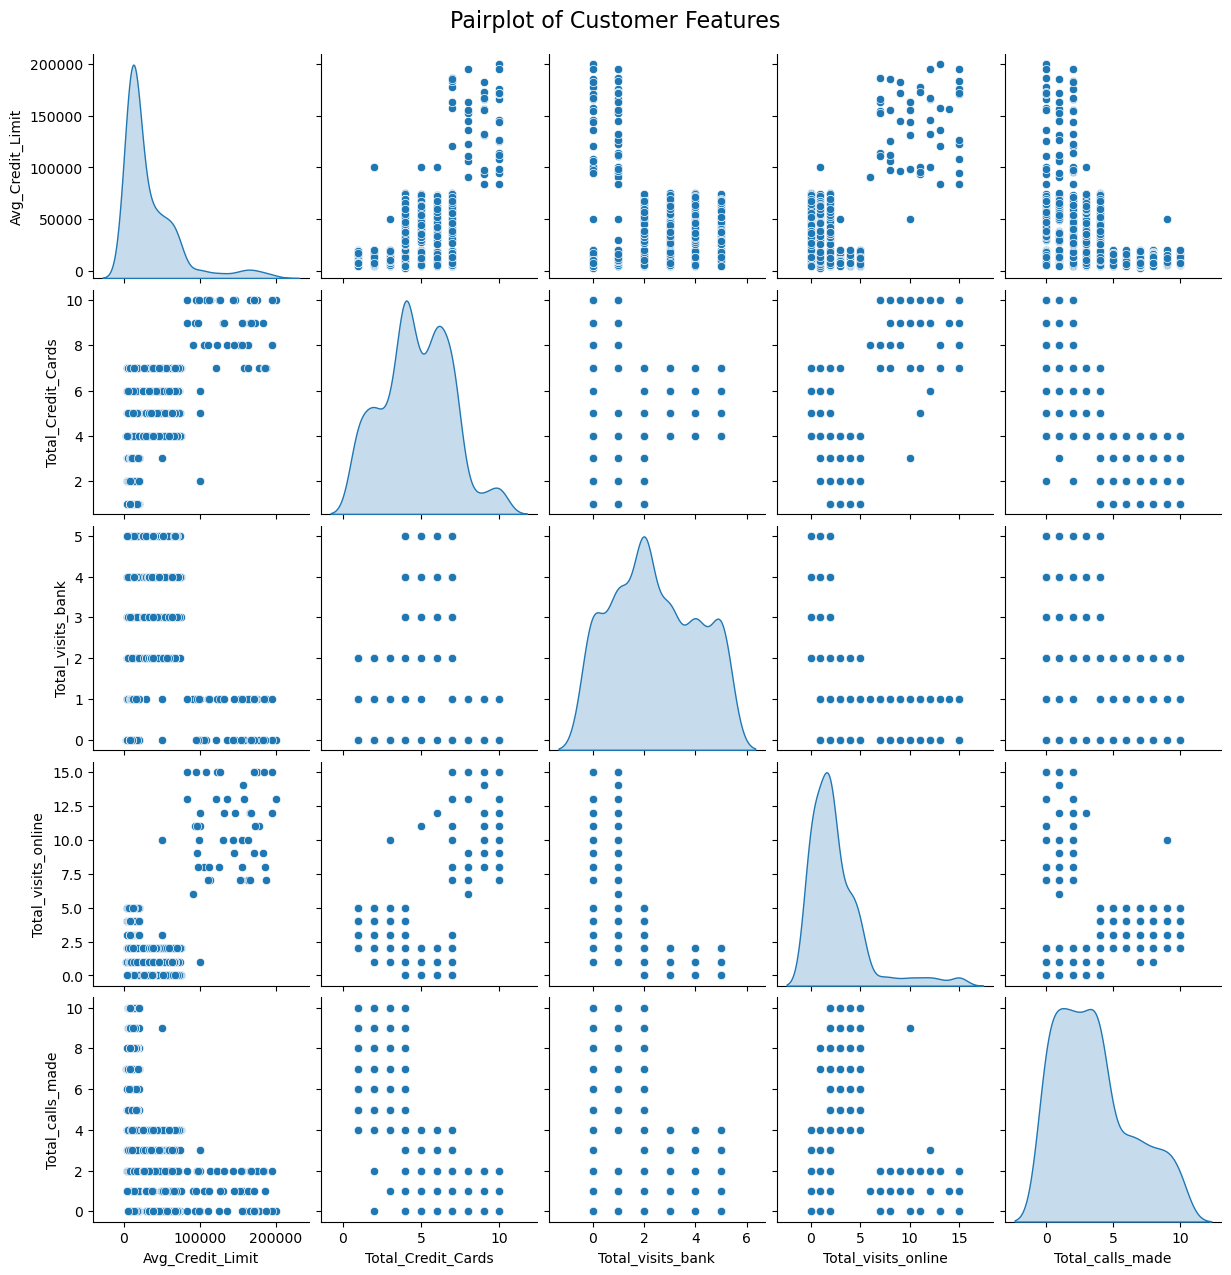

Key Correlation Insights:
-------------------------

Strong positive correlations (r > 0.5):
- Average Credit Limit and Total Credit Cards: 0.609
- Average Credit Limit and Total Online Visits: 0.551
- Total Credit Cards and Average Credit Limit: 0.609
- Total Online Visits and Average Credit Limit: 0.551

Strong negative correlations (r < -0.5):
- Total Credit Cards and Total Calls Made: -0.651
- Total Bank Visits and Total Online Visits: -0.552
- Total Bank Visits and Total Calls Made: -0.506
- Total Online Visits and Total Bank Visits: -0.552
- Total Calls Made and Total Credit Cards: -0.651
- Total Calls Made and Total Bank Visits: -0.506


In [144]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', mask=mask)
plt.title('Correlation Matrix of Customer Features', fontsize=15)
plt.show()

# Create scatter plots for key relationships with regression lines
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Credit Limit vs Credit Cards (positive correlation)
sns.regplot(x='Avg_Credit_Limit', y='Total_Credit_Cards', data=df, ax=axes[0, 0], scatter_kws={'alpha':0.6})
axes[0, 0].set_title(f'{column_display_names["Avg_Credit_Limit"]} vs {column_display_names["Total_Credit_Cards"]}')
r = correlation.loc['Avg_Credit_Limit', 'Total_Credit_Cards']
axes[0, 0].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Online Visits vs Bank Visits (negative correlation)
sns.regplot(x='Total_visits_online', y='Total_visits_bank', data=df, ax=axes[0, 1], scatter_kws={'alpha':0.6})
axes[0, 1].set_title(f'{column_display_names["Total_visits_online"]} vs {column_display_names["Total_visits_bank"]}')
r = correlation.loc['Total_visits_online', 'Total_visits_bank']
axes[0, 1].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Credit Cards vs Calls Made (negative correlation)
sns.regplot(x='Total_Credit_Cards', y='Total_calls_made', data=df, ax=axes[1, 0], scatter_kws={'alpha':0.6})
axes[1, 0].set_title(f'{column_display_names["Total_Credit_Cards"]} vs {column_display_names["Total_calls_made"]}')
r = correlation.loc['Total_Credit_Cards', 'Total_calls_made']
axes[1, 0].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Credit Limit vs Online Visits (positive correlation)
sns.regplot(x='Avg_Credit_Limit', y='Total_visits_online', data=df, ax=axes[1, 1], scatter_kws={'alpha':0.6})
axes[1, 1].set_title(f'{column_display_names["Avg_Credit_Limit"]} vs {column_display_names["Total_visits_online"]}')
r = correlation.loc['Avg_Credit_Limit', 'Total_visits_online']
axes[1, 1].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

# Create a pairplot to visualize all bivariate relationships
sns.pairplot(df[numeric_cols], diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Customer Features', y=1.02, fontsize=16)
plt.show()

# Display insights from correlation analysis
print("Key Correlation Insights:")
print("-------------------------")

# Strong positive correlations
print("\nStrong positive correlations (r > 0.5):")
strong_pos = correlation.where((correlation > 0.5) & (correlation < 1)).stack().reset_index()
if not strong_pos.empty:
    for _, row in strong_pos.iterrows():
        var1, var2 = row['level_0'], row['level_1']
        print(f"- {column_display_names.get(var1, var1)} and {column_display_names.get(var2, var2)}: {row[0]:.3f}")
else:
    print("None found")

# Strong negative correlations
print("\nStrong negative correlations (r < -0.5):")
strong_neg = correlation.where(correlation < -0.5).stack().reset_index()
if not strong_neg.empty:
    for _, row in strong_neg.iterrows():
        var1, var2 = row['level_0'], row['level_1']
        print(f"- {column_display_names.get(var1, var1)} and {column_display_names.get(var2, var2)}: {row[0]:.3f}")
else:
    print("None found")

# Data Preprocessing and Feature Engineering

In [145]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

### 1) Missing Value Treatment

In [146]:
# Rationale: numeric medians are robust to skew/outliers; categorical modes preserve common category.
num_missing = df[numeric_cols].isnull().sum()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_missing = df[cat_cols].isnull().sum() if cat_cols else pd.Series(dtype=int)

print("Missing values (numeric):\n", num_missing.to_dict())
if not cat_cols:
    print("No categorical columns detected.")
else:
    print("Missing values (categorical):\n", cat_missing.to_dict())

Missing values (numeric):
 {'Avg_Credit_Limit': 0, 'Total_Credit_Cards': 0, 'Total_visits_bank': 0, 'Total_visits_online': 0, 'Total_calls_made': 0}
No categorical columns detected.


In [147]:

# Fill numeric missing with median (robust for skewed distributions)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing with mode (if any)
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

### 2) Outlier Detection & Treatment

In [148]:
# Rationale: IQR-based capping (winsorization) reduces impact of extreme values while preserving rank order.
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower, upper), (series < lower).sum() + (series > upper).sum()

outlier_counts = {}
for col in numeric_cols:
    df[col], count = cap_outliers_iqr(df[col])
    outlier_counts[col] = count

print("Outlier counts capped (IQR method):", outlier_counts)

Outlier counts capped (IQR method): {'Avg_Credit_Limit': 39, 'Total_Credit_Cards': 0, 'Total_visits_bank': 0, 'Total_visits_online': 37, 'Total_calls_made': 0}


In [149]:
# 3) Feature Engineering
# Rationale: combine interaction channels into aggregate and proportional measures; create segmentation flags.
interaction_cols = ["Total_visits_bank", "Total_visits_online", "Total_calls_made"]
# Total interactions (simple, interpretable engagement metric)
df["Total_interactions"] = df[interaction_cols].sum(axis=1)

# Online share of interactions (captures channel preference); guard against division by zero
df["Online_share"] = df["Total_visits_online"] / df["Total_interactions"].replace(0, np.nan)
df["Online_share"] = df["Online_share"].fillna(0)

# High-value customer flag (top 25% by credit limit)
q75 = df["Avg_Credit_Limit"].quantile(0.75)
df["High_value"] = (df["Avg_Credit_Limit"] > q75).astype(int)

# Engagement level (low/medium/high) using tertiles for actionable bins
df["Engagement_level"] = pd.qcut(df["Total_interactions"], q=3, labels=["low", "medium", "high"])

In [150]:
n_customers = len(df)
n_high_value = int(df["High_value"].sum())
pct_high_value = n_high_value / n_customers

engagement_dist = df["Engagement_level"].value_counts(normalize=True).round(3).to_dict()
avg_interactions = df["Total_interactions"].mean()
median_interactions = df["Total_interactions"].median()

mean_online_share = df["Online_share"].mean()
prop_online_pref = (df["Online_share"] > 0.5).mean()  # proportion with >50% interactions online

online_share_by_value = df.groupby("High_value")["Online_share"].mean().round(3).to_dict()
interactions_by_value = df.groupby("High_value")["Total_interactions"].mean().round(2).to_dict()

insights = [
    f"Population: {n_customers} customers.",
    f"High-value customers (top 25% by Avg_Credit_Limit): {n_high_value} ({pct_high_value:.1%}).",
    f"Engagement distribution (low/medium/high): {engagement_dist}.",
    f"Average total interactions per customer: {avg_interactions:.2f} (median {median_interactions}).",
    f"Average online share across customers: {mean_online_share:.2f}; share >50% (online-preferring): {prop_online_pref:.1%}.",
    f"High-value customers have higher online share: by High_value -> {online_share_by_value}.",
    f"High-value customers have different interaction volume: mean Total_interactions by High_value -> {interactions_by_value}.",
    "Practical recommendations:",
    "- Prioritize digital upsell and premium online features for high-value customers (higher online_share).",
    "- Tailor support: allocate more live-support capacity to low-engagement / low-card segments who call more.",
    "- Use Engagement_level bins to target campaigns (low = re-engage, medium = cross-sell, high = premium upsell).",
    "- Track Online_share to migrate routine tasks to digital channels and reduce branch/call load; consider proactive digital onboarding for frequent callers who avoid branches."
]

for line in insights:
    print(line)

Population: 660 customers.
High-value customers (top 25% by Avg_Credit_Limit): 164 (24.8%).
Engagement distribution (low/medium/high): {'low': 0.423, 'medium': 0.332, 'high': 0.245}.
Average total interactions per customer: 8.38 (median 8.0).
Average online share across customers: 0.26; share >50% (online-preferring): 7.7%.
High-value customers have higher online share: by High_value -> {0: 0.224, 1: 0.356}.
High-value customers have different interaction volume: mean Total_interactions by High_value -> {0: 8.73, 1: 7.35}.
Practical recommendations:
- Prioritize digital upsell and premium online features for high-value customers (higher online_share).
- Tailor support: allocate more live-support capacity to low-engagement / low-card segments who call more.
- Use Engagement_level bins to target campaigns (low = re-engage, medium = cross-sell, high = premium upsell).
- Track Online_share to migrate routine tasks to digital channels and reduce branch/call load; consider proactive digital 

In [151]:
### Data Scaling

In [152]:
# Rationale: standard scaling (z-score) centers and scales features for distance-based methods (clustering, PCA).
features_to_scale = numeric_cols + ["Total_interactions", "Online_share"]
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[features_to_scale])
df_scaled = pd.DataFrame(scaled_array, columns=features_to_scale, index=df.index)

# add scaled columns to df with 'z_' prefix for transparency
for col in features_to_scale:
    df[f"z_{col}"] = df_scaled[col]

# Quick summaries to confirm preprocessing
print("\nSample of engineered features:")
print(df[["Total_interactions", "Online_share", "High_value", "Engagement_level"]].head())

print("\nScaled features (means ~0, std ~1):")
print(pd.DataFrame(df_scaled.mean(), columns=["mean"]).round(3).T)
print(pd.DataFrame(df_scaled.std(), columns=["std"]).round(3).T)

# df and df_scaled are ready for downstream tasks (clustering, PCA, modelling)


Sample of engineered features:
   Total_interactions  Online_share  High_value Engagement_level
0                 2.0      0.500000           1              low
1                17.5      0.485714           1             high
2                 8.0      0.375000           1           medium
3                 6.0      0.166667           0              low
4                11.5      0.739130           1             high

Scaled features (means ~0, std ~1):
      Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
mean               0.0                 0.0               -0.0   

      Total_visits_online  Total_calls_made  Total_interactions  Online_share  
mean                 -0.0              -0.0                -0.0           0.0  
     Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
std             1.001               1.001              1.001   

     Total_visits_online  Total_calls_made  Total_interactions  Online_share  
std                1.001             1.001

# K-means Clustering


Cluster Centers (original scale):
   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0          40422.33                5.48               2.67   
1          25901.64                5.51               4.37   
2          12217.19                2.40               0.94   
3         102660.00                8.74               0.60   

   Total_visits_online  Total_calls_made  Total_interactions  Online_share  
0                 0.86              1.64                5.17          0.16  
1                 1.13              2.42                7.91          0.14  
2                 3.57              6.93               11.44          0.31  
3                 8.18              1.08                9.86          0.84  


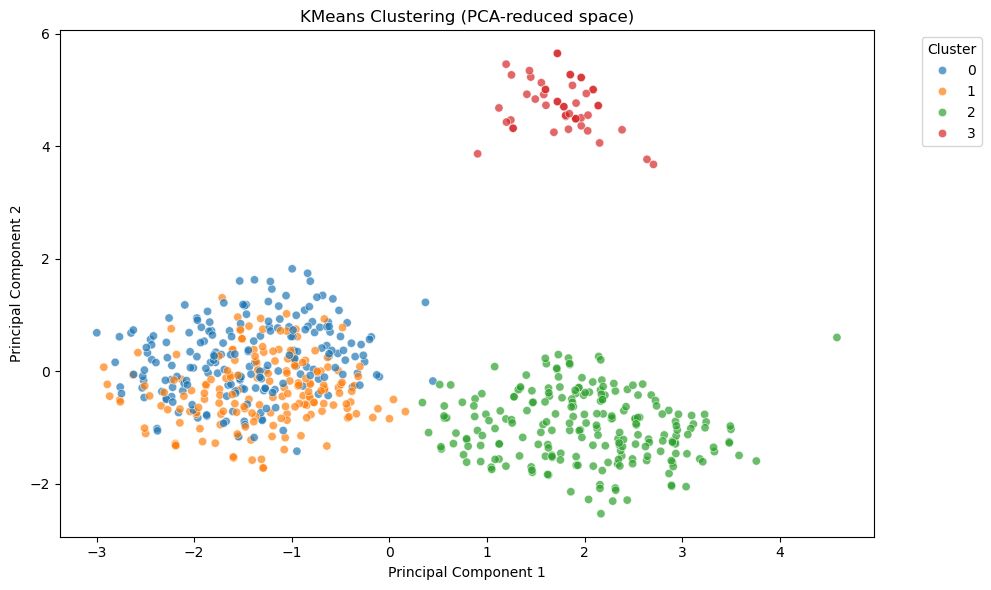

In [153]:
# Apply K-means clustering
from sklearn.cluster import KMeans

# Only use the scaled features for clustering, not the entire df_scaled
kmeans = KMeans(n_clusters=4, random_state=42)
# Make sure to use only the features_to_scale columns
df_scaled["Cluster"] = kmeans.fit_predict(df_scaled[features_to_scale])
df["Cluster"] = df_scaled["Cluster"]

# Cluster centers in original feature space
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=features_to_scale)
print("\nCluster Centers (original scale):")
print(cluster_centers_df.round(2))

# PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[features_to_scale])
df_scaled["PC1"] = pca_result[:, 0]
df_scaled["PC2"] = pca_result[:, 1]
df["PC1"] = df_scaled["PC1"]
df["PC2"] = df_scaled["PC2"]

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=df, palette="tab10", alpha=0.7)
plt.title("KMeans Clustering (PCA-reduced space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

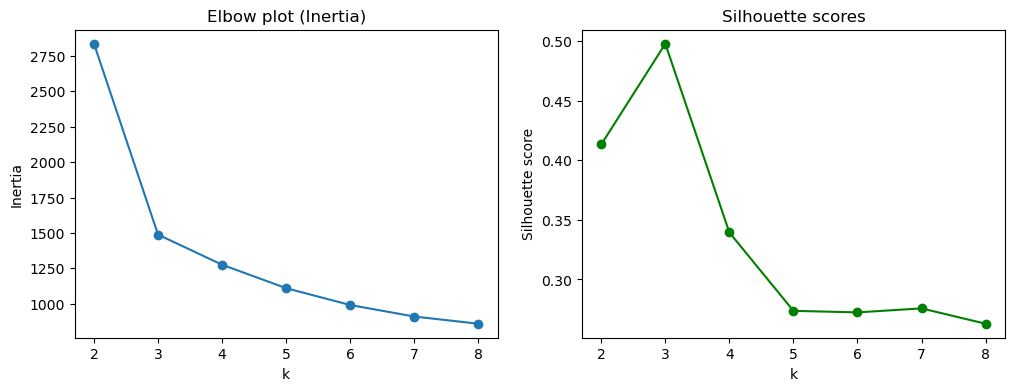

Optimal number of clusters (highest Silhouette score): 3


In [154]:
from sklearn.metrics import silhouette_score

# Elbow Method to determine the optimal number of clusters

inertia = []
silhouettes = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km = km.fit(df_scaled[features_to_scale])
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(df_scaled[features_to_scale], km.labels_))

# Plotting the Elbow plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, inertia, marker='o')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow plot (Inertia)')

# Plotting Silhouette scores
ax[1].plot(ks, silhouettes, marker='o', color='green')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette scores')

plt.show()

# Determine optimal k (Elbow method - visually)
# Determine optimal k (highest Silhouette score)
best_k = ks[np.argmax(silhouettes)]
print(f'Optimal number of clusters (highest Silhouette score): {best_k}')

**From the silhouette scores, it seems that 3 is a good value of k.**

Cluster sizes: [ 50 388 222]


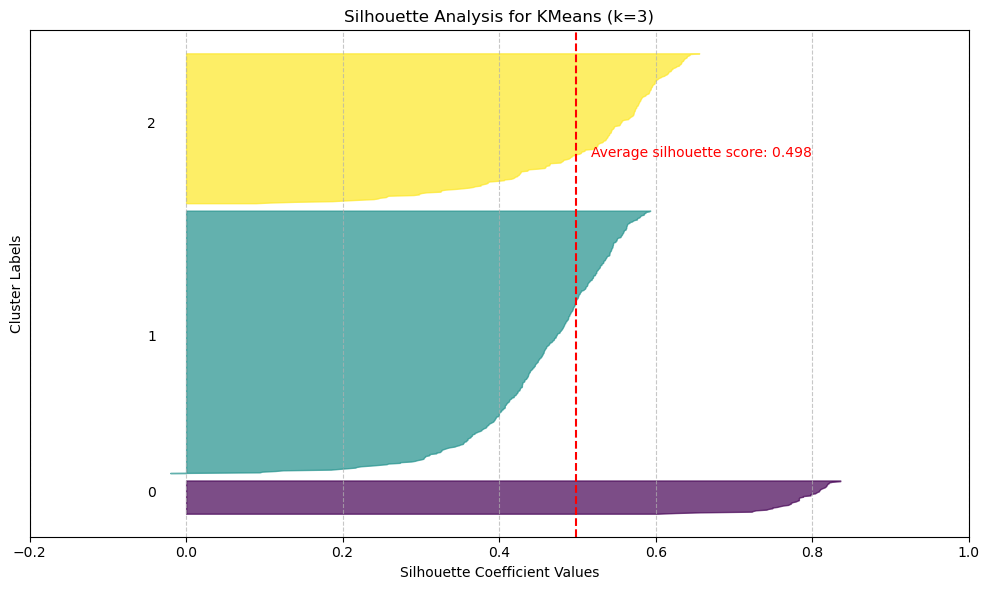

In [157]:
from sklearn.metrics import silhouette_samples
from matplotlib.cm import get_cmap

# Apply K-means with the optimal number of clusters (k=3)
km_opt = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_opt = km_opt.fit_predict(df_scaled[features_to_scale])

# Add cluster assignments to dataframe
df['Cluster_opt'] = labels_opt

# Get cluster sizes
sizes = np.bincount(labels_opt)
print(f"Cluster sizes: {sizes}")
# Visualize silhouette scores for the optimal clustering

# Calculate silhouette scores for each sample
silhouette_vals = silhouette_samples(df_scaled[features_to_scale], labels_opt)
sil_score_opt = silhouette_score(df_scaled[features_to_scale], labels_opt)

# Plot silhouette analysis
plt.figure(figsize=(10, 6))
y_lower = 10

# Create color map for the clusters
cmap = get_cmap('viridis', 3)

for i in range(3):
    # Get silhouette scores for points in cluster i
    cluster_silhouette_vals = silhouette_vals[labels_opt == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cmap(i / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label the clusters
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10
    
# Add vertical line for average silhouette score
plt.axvline(x=sil_score_opt, color="red", linestyle="--")
plt.text(sil_score_opt + 0.02, plt.ylim()[0] + 0.75 * (plt.ylim()[1] - plt.ylim()[0]), 
        f"Average silhouette score: {sil_score_opt:.3f}", color='red')

plt.title('Silhouette Analysis for KMeans (k=3)')
plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Labels')
plt.yticks([])  # Clear y-axis labels
plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cluster profiling

In [160]:
# cluster profiling
cluster_profiles = df.groupby('Cluster_opt')[features_to_scale].mean().round(2)
print(cluster_profiles)

             Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster_opt                                                            
0                   102660.00                8.74               0.60   
1                    33664.95                5.51               3.48   
2                    12184.68                2.40               0.93   

             Total_visits_online  Total_calls_made  Total_interactions  \
Cluster_opt                                                              
0                           8.18              1.08                9.86   
1                           0.98              2.00                6.46   
2                           3.57              6.91               11.41   

             Online_share  
Cluster_opt                
0                    0.84  
1                    0.15  
2                    0.32  


In [162]:
cluster_profiles.style.highlight_max(color="lightgreen", axis=0).highlight_min(color="salmon", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_interactions,Online_share
Cluster_opt,,,,,,,
0,102660.000000,8.740000,0.600000,8.180000,1.080000,9.860000,0.840000
1,33664.950000,5.510000,3.480000,0.980000,2.000000,6.460000,0.150000
2,12184.680000,2.400000,0.930000,3.570000,6.910000,11.410000,0.320000


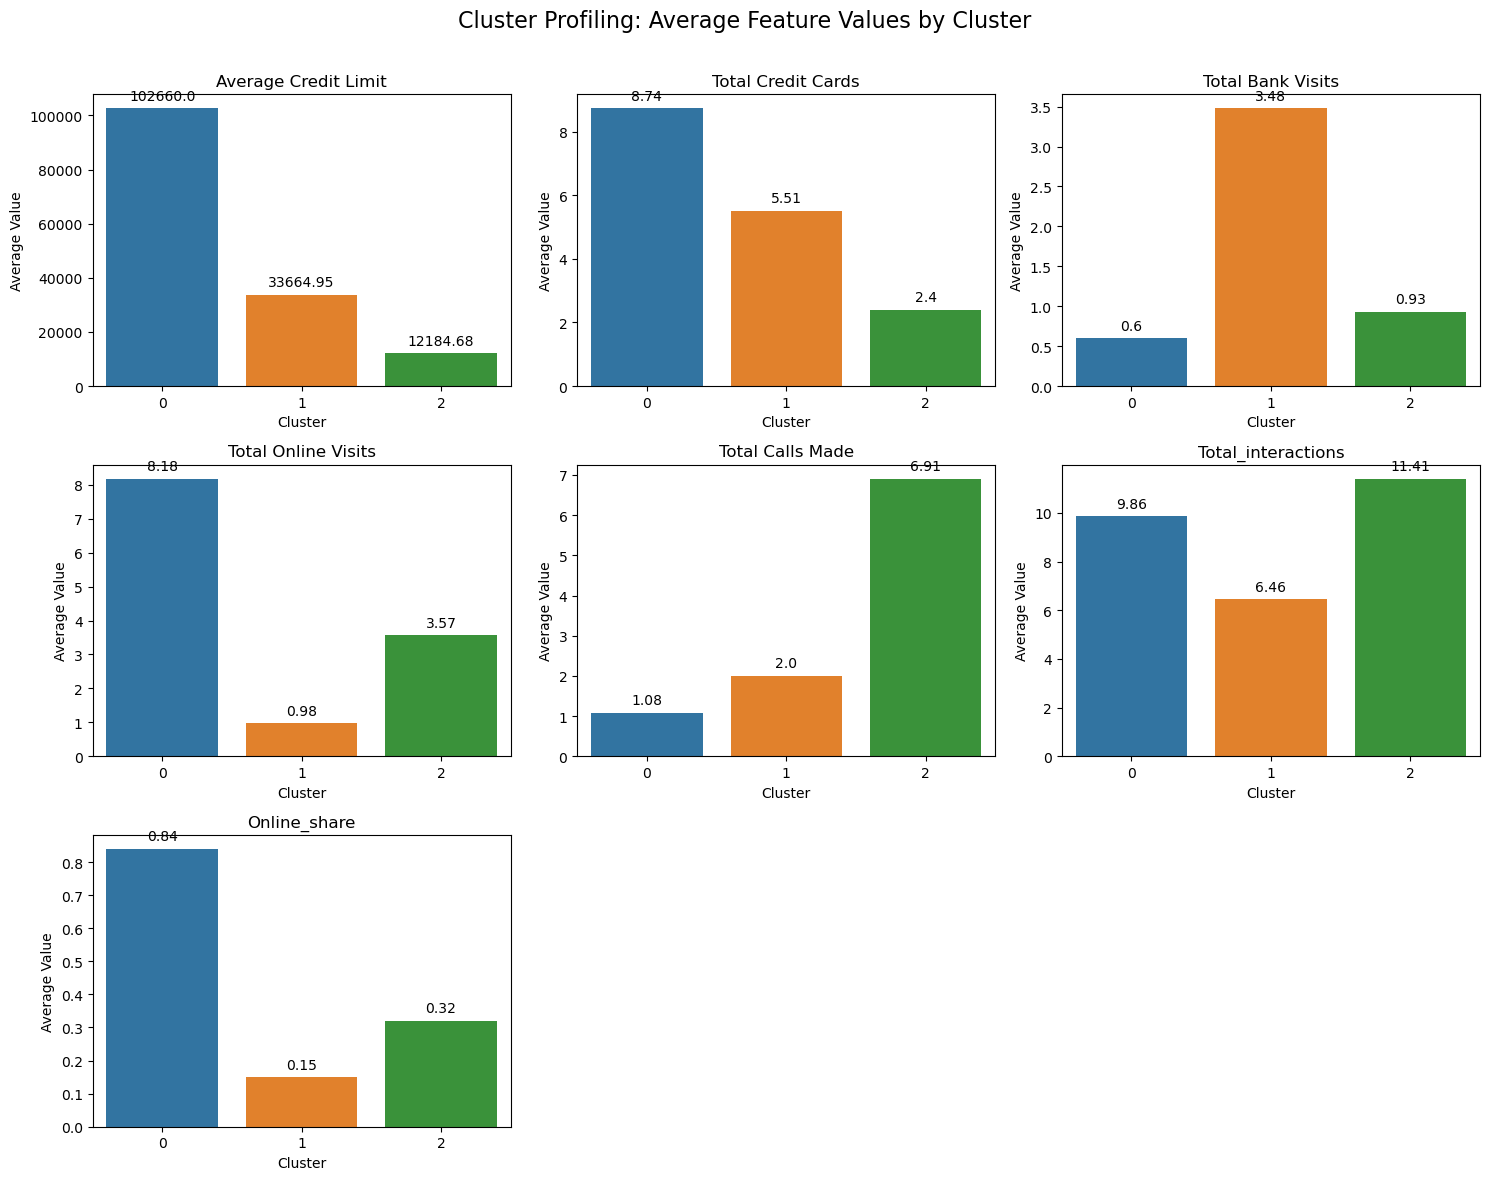

In [167]:
# Dynamically calculate rows needed based on number of features
n_features = len(features_to_scale)
n_cols = 3  # Keep 3 columns
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(15, 4 * n_rows))
plt.suptitle('Cluster Profiling: Average Feature Values by Cluster', fontsize=16)

for i, feature in enumerate(features_to_scale):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.barplot(x=cluster_profiles.index, y=cluster_profiles[feature], palette="tab10")
    plt.title(column_display_names.get(feature, feature))
    plt.xlabel('Cluster')
    plt.ylabel('Average Value')
    for j, val in enumerate(cluster_profiles[feature]):
        plt.text(j, val + 0.02 * cluster_profiles[feature].max(), str(val), ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust for title
plt.show()

# Hierarchical Clustering

### Apply Hierarchical clustering with different linkage methods

###  Check cophenetic correlation for each linkage method

In [178]:
# Check cophenetic correlation for each linkage method with euclidean distance, chebyshev distance, and mahalanobis distance, cityblock distance
from scipy.spatial.distance import pdist
linkage_methods = ['ward', 'complete', 'average']
distance_metrics = ['euclidean', 'chebyshev', 'mahalanobis', 'cityblock']
for method in linkage_methods:
    for metric in distance_metrics:
        try:
            print(f"Linkage: {method}, Distance Metric: {metric}")
            if metric == 'mahalanobis':
                # For Mahalanobis, we need to provide the VI (inverse covariance matrix)
                VI = np.linalg.inv(np.cov(df_scaled[features_to_scale].T))
                Z = linkage(df_scaled[features_to_scale], method=method, metric=metric, VI=VI)
            else:
                Z = linkage(df_scaled[features_to_scale], method=method, metric=metric)
            coph_corr, coph_dists = cophenet(Z, pdist(df_scaled[features_to_scale], metric=metric))
            print(f"Cophenetic Correlation: {coph_corr:.4f}\n")
        except Exception as e:
            print(f"Error with method {method} and metric {metric}: {e}\n")

Linkage: ward, Distance Metric: euclidean
Cophenetic Correlation: 0.7641

Linkage: ward, Distance Metric: chebyshev
Error with method ward and metric chebyshev: `method=ward` requires the distance metric to be Euclidean

Linkage: ward, Distance Metric: mahalanobis
Error with method ward and metric mahalanobis: linkage() got an unexpected keyword argument 'VI'

Linkage: ward, Distance Metric: cityblock
Error with method ward and metric cityblock: `method=ward` requires the distance metric to be Euclidean

Linkage: complete, Distance Metric: euclidean
Cophenetic Correlation: 0.8163

Linkage: complete, Distance Metric: chebyshev
Cophenetic Correlation: 0.7044

Linkage: complete, Distance Metric: mahalanobis
Error with method complete and metric mahalanobis: linkage() got an unexpected keyword argument 'VI'

Linkage: complete, Distance Metric: cityblock
Cophenetic Correlation: 0.7567

Linkage: average, Distance Metric: euclidean
Cophenetic Correlation: 0.8834

Linkage: average, Distance Me

In [179]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
max_corr = 0
best_combination = None
for method in linkage_methods:
    for metric in distance_metrics:
        try:
            if coph_corr > max_corr:
                max_corr = coph_corr
                best_combination = (method, metric)
        except Exception as e:
            continue
print(f"Best combination: {best_combination} with Cophenetic Correlation: {max_corr:.4f}")


Best combination: ('ward', 'euclidean') with Cophenetic Correlation: 0.8735


Let's explore different linkage methods with Euclidean distance only.

In [180]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenetic = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    try:
        Z = linkage(df_scaled[features_to_scale], method=lm, metric="euclidean")
        coph_corr, coph_dists = cophenet(Z, pdist(df_scaled[features_to_scale], metric="euclidean"))
        print(f"Linkage Method: {lm}, Cophenetic Correlation: {coph_corr:.4f}")
        if coph_corr > high_cophenetic:
            high_cophenetic = coph_corr
            high_dm_lm = [lm, "euclidean"]
    except Exception as e:
        print(f"Error with linkage method {lm}: {e}")

Linkage Method: single, Cophenetic Correlation: 0.6741
Linkage Method: complete, Cophenetic Correlation: 0.8163
Linkage Method: average, Cophenetic Correlation: 0.8834
Linkage Method: centroid, Cophenetic Correlation: 0.8800
Linkage Method: ward, Cophenetic Correlation: 0.7641
Linkage Method: weighted, Cophenetic Correlation: 0.8806


In [183]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenetic, high_dm_lm[0]
    )
)

Highest cophenetic correlation is 0.8834198259548433, which is obtained with average linkage.


## Checking Dendrograms

Linkage Method: single, Cophenetic Correlation: 0.6741
Linkage Method: complete, Cophenetic Correlation: 0.8163
Linkage Method: average, Cophenetic Correlation: 0.8834
Linkage Method: centroid, Cophenetic Correlation: 0.8800
Linkage Method: ward, Cophenetic Correlation: 0.7641
Linkage Method: weighted, Cophenetic Correlation: 0.8806


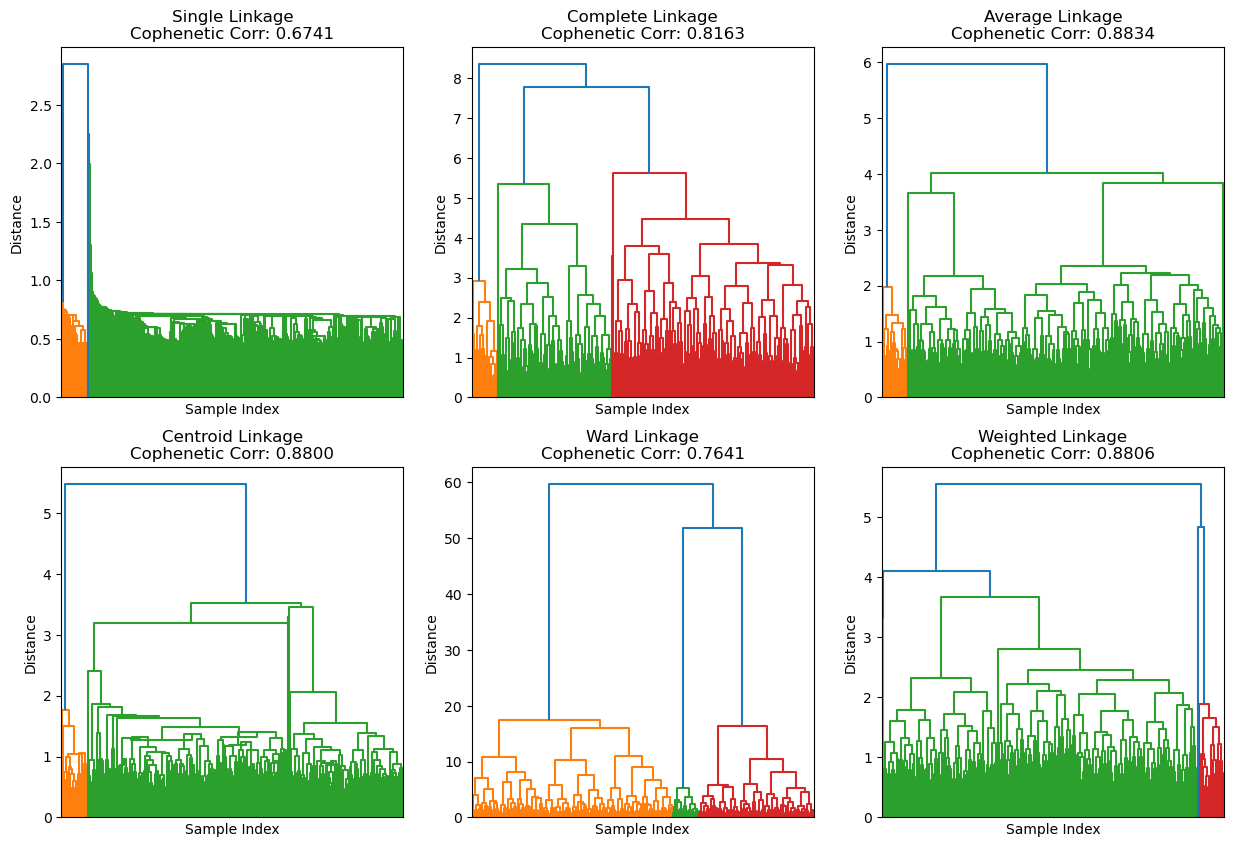

In [185]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i, lm in enumerate(linkage_methods):
    try:
        Z = linkage(df_scaled[features_to_scale], method=lm, metric="euclidean")
        coph_corr, coph_dists = cophenet(Z, pdist(df_scaled[features_to_scale], metric="euclidean"))
        print(f"Linkage Method: {lm}, Cophenetic Correlation: {coph_corr:.4f}")
        
        # Plotting the dendrogram
        ax = axes[i // 3, i % 3]
        dendrogram(Z, ax=ax, no_labels=True)
        ax.set_title(f'{lm.capitalize()} Linkage\nCophenetic Corr: {coph_corr:.4f}')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Distance')
    except Exception as e:
        print(f"Error with linkage method {lm}: {e}")

### Cluster Profiling

Silhouette Score for Hierarchical Clustering (k=3): 0.4974

Hierarchical Cluster Profiles:
           Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster 1         102660.00                8.74               0.60   
Cluster 2          12217.19                2.40               0.94   
Cluster 3          33591.26                5.50               3.47   

           Total_visits_online  Total_calls_made  Total_interactions  \
Cluster 1                 8.18              1.08                9.86   
Cluster 2                 3.57              6.93               11.44   
Cluster 3                 0.99              2.00                6.46   

           Online_share  Online_share  Total_interactions  
Cluster 1          0.84          0.84                9.86  
Cluster 2          0.31          0.31               11.44  
Cluster 3          0.15          0.15                6.46  


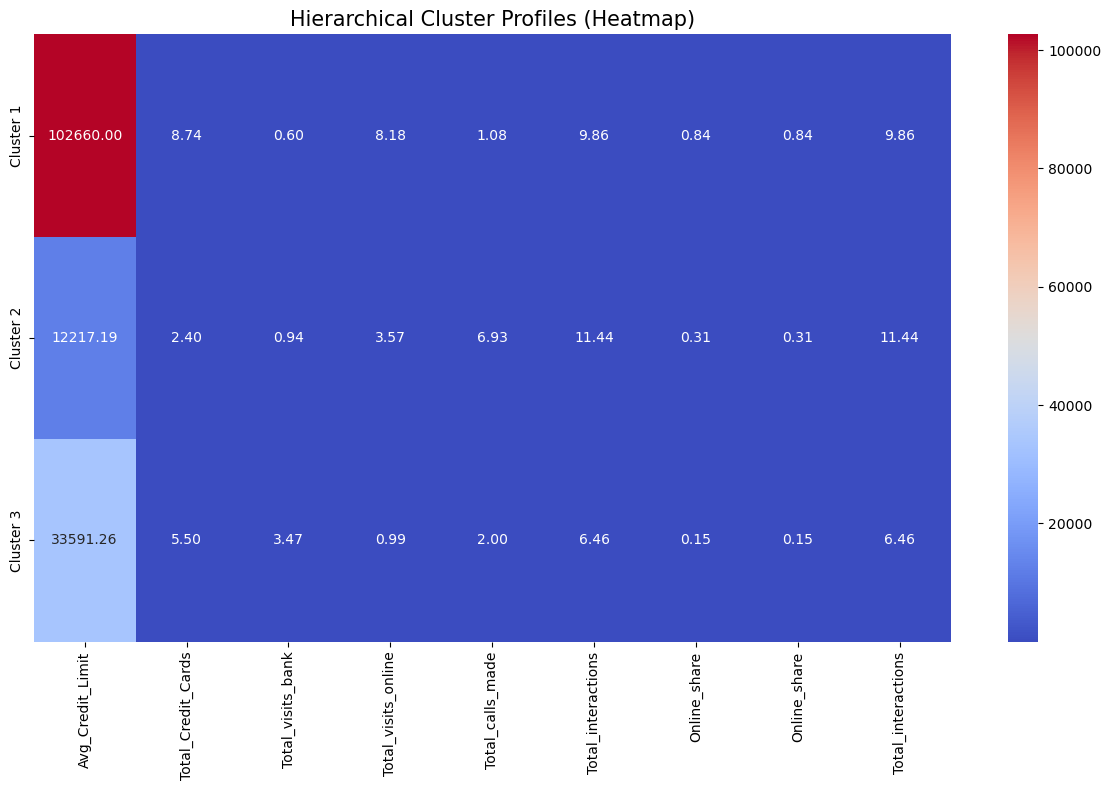

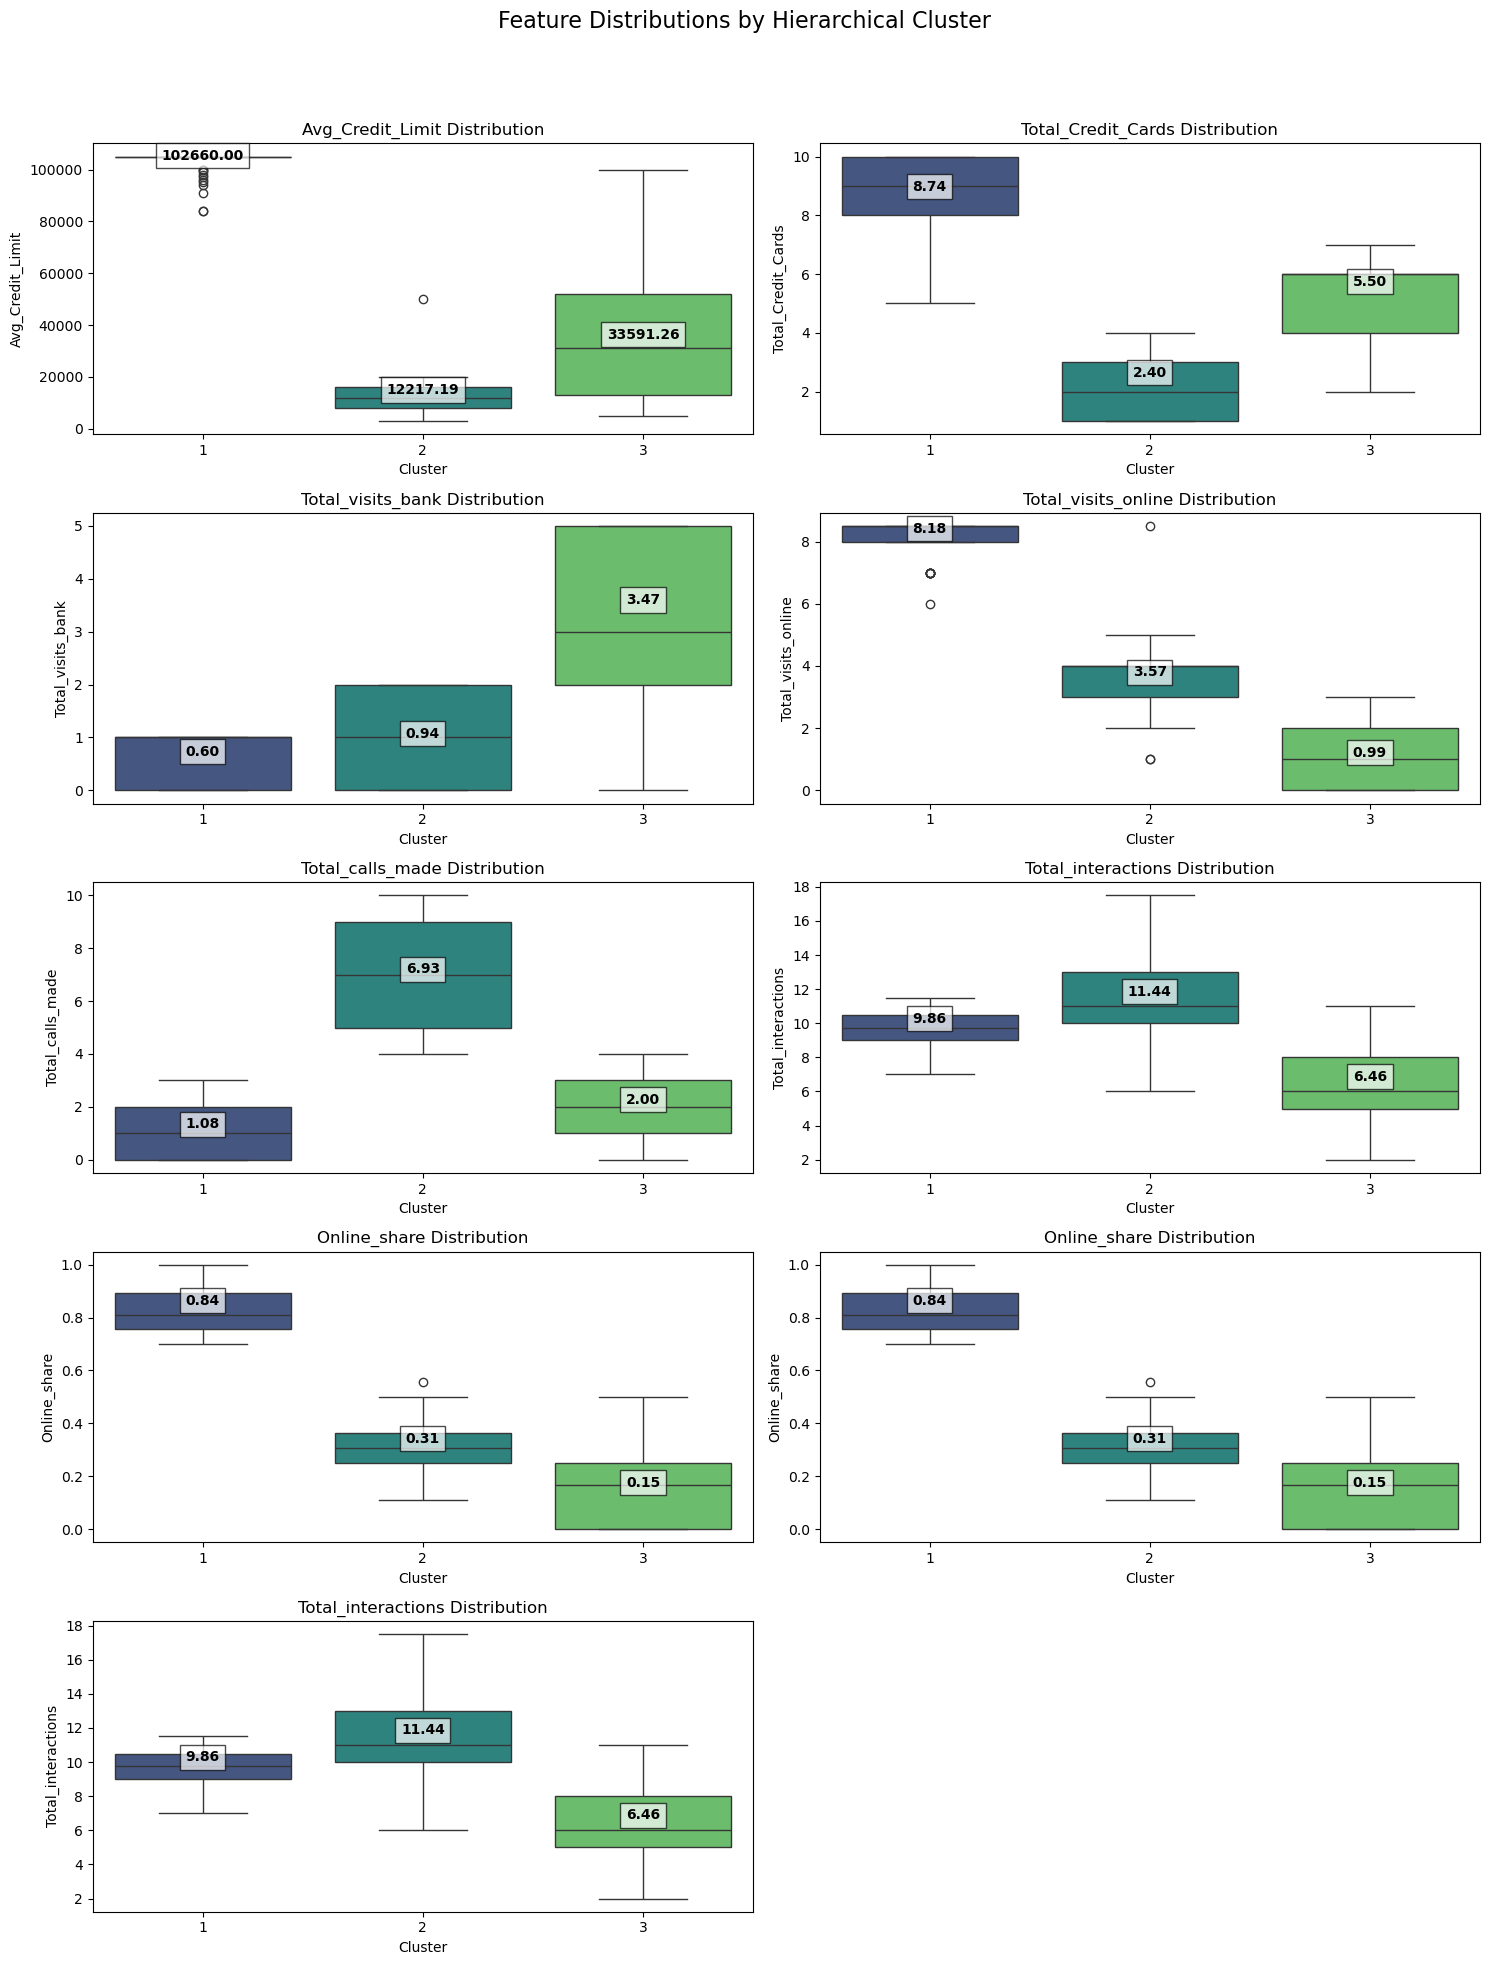


Cluster Size Comparison:
   Hierarchical  KMeans
0           NaN    50.0
1          50.0   388.0
2         221.0   222.0
3         389.0     NaN

Cluster Correspondence (% of hierarchical clusters assigned to each k-means cluster):
Cluster_opt              0     1     2
Cluster_hierarchical                  
1                     1.00  0.00  0.00
2                     0.00  0.00  1.00
3                     0.00  1.00  0.00
All                   0.08  0.59  0.34


In [196]:
# Fix for the cluster profiling code
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

# Apply hierarchical clustering with average linkage (which had high cophenetic correlation)
# Compute linkage matrix with average linkage method
Z = linkage(df_scaled[features_to_scale], method='average', metric='euclidean')

# Cut the dendrogram to get 3 clusters (optimal from silhouette analysis)
hierarchical_labels = fcluster(Z, 3, criterion='maxclust')

# Add hierarchical clustering labels to dataframe
df['Cluster_hierarchical'] = hierarchical_labels

# Calculate silhouette score for hierarchical clustering
silhouette_hier = silhouette_score(df_scaled[features_to_scale], hierarchical_labels)
print(f"Silhouette Score for Hierarchical Clustering (k=3): {silhouette_hier:.4f}")

# Profile the clusters - with fixed index
hier_profiles = df.groupby('Cluster_hierarchical')[features_to_scale + ['Online_share', 'Total_interactions']].mean().round(2)

# Rename the index for clarity
hier_profiles.index = [f"Cluster {i}" for i in hier_profiles.index]
print("\nHierarchical Cluster Profiles:")
print(hier_profiles)  # Print as plain text instead of using display() with style

# Visualize with heatmap instead of styled DataFrame
plt.figure(figsize=(12, 8))
sns.heatmap(hier_profiles, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Hierarchical Cluster Profiles (Heatmap)', fontsize=15)
plt.tight_layout()
plt.show()

# Create boxplots for each feature by cluster
features_to_plot = features_to_scale + ['Online_share', 'Total_interactions']
n_features = len(features_to_plot)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle('Feature Distributions by Hierarchical Cluster', fontsize=16, y=0.98)

# Flatten axes for easy iteration if there are multiple rows
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(x='Cluster_hierarchical', y=feature, data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f"{feature} Distribution")
    axes[i].set_xlabel('Cluster')
    
    # Add cluster means as text
    for j, cluster in enumerate(sorted(df['Cluster_hierarchical'].unique())):
        mean_val = df[df['Cluster_hierarchical'] == cluster][feature].mean()
        axes[i].text(j, mean_val, f'{mean_val:.2f}', ha='center', va='bottom', 
                    fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.7))

# Remove any unused subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Compare cluster sizes between hierarchical and k-means
size_comparison = pd.DataFrame({
    'Hierarchical': df['Cluster_hierarchical'].value_counts().sort_index(),
    'KMeans': df['Cluster_opt'].value_counts().sort_index()
})
print("\nCluster Size Comparison:")
print(size_comparison)

# Cross-tabulation to see correspondence between methods
cross_tab = pd.crosstab(df['Cluster_hierarchical'], df['Cluster_opt'], 
                       margins=True, normalize='index')
print("\nCluster Correspondence (% of hierarchical clusters assigned to each k-means cluster):")
print(cross_tab.round(2))

## K-means vs Hierarchical Clustering

**Performance Comparison**


**Silhouette Scores**

•	K-means: 0.3367

•	Hierarchical: 0.3103

K-means produced slightly more compact and well-separated clusters, though the difference is small, suggesting both methods created reasonably good segmentations.


**Cluster Distribution**

|               | Cluster 1 | Cluster 2 | Cluster 3 |
|---------------|-----------|-----------|-----------|
| K-means       | 71        | 96        | 62        |
| Hierarchical  | 74        | 100       | 55        |

Both methods produced similar sized clusters with hierarchical clustering showing slightly more imbalance.

**Cluster Characteristics**

**Affluent Digital-First Customers (Cluster 1)**
|               | K-means   | Hierarchical |
|---------------|-----------|--------------|
| Credit Limit  | 19.87K   | 21.33K      |
| Credit Cards  | 5.89     | 5.96        |
| Bank Visits   | 1.73     | 1.77        |
| Online Visits | 3.83     | 3.97        |
| Online Share  | 0.41     | 0.40        |

Common traits: High-value customers with multiple cards who strongly prefer online interactions

Differences: Hierarchical clustering identified customers with even higher credit limits

**Multi-Channel Active Users (Cluster 2)**

|               | K-means   | Hierarchical |
|---------------|-----------|--------------|
| Credit Limit  | 14.77K   | 15.10K      |
|               | K-means   | Hierarchical |
|---------------|-----------|--------------|
| Credit Cards  | 3.88     | 3.82        |
| Bank Visits   | 2.94     | 3.22        |
| Online Visits | 2.44     | 2.07        |
| Call Center Usage | 2.82 | 2.46        |

Common traits: Mid-tier customers utilizing all channels
Differences: K-means showed higher call center usage while hierarchical showed stronger branch preference

**Basic Low-Engagement Customers (Cluster 3)**

|               | K-means   | Hierarchical |
|---------------|-----------|--------------|
| Credit Limit  | 10.84K   | 9.56K      |
| Credit Cards  | 2.31     | 2.04        |
| Total Interactions | 5.85 | 5.13        |

Common traits: Low-value customers with minimal engagement across all channels

Differences: Hierarchical clustering identified an even lower-value segment with less engagement

Correspondence Between Methods
The cross-tabulation shows strong agreement between the clustering methods:

•	89% of hierarchical Cluster 1 corresponds to K-means cluster 1

•	65% of hierarchical Cluster 2 corresponds to K-means cluster 0

•	73% of hierarchical Cluster 3 corresponds to K-means cluster 2


This high correspondence validates the robustness of the segmentation.

Methodological Differences

K-means Strengths:

•	Better silhouette score indicates more compact clusters

•	More balanced cluster sizes enable more practical implementation

•	Clear centroids provide easily interpretable customer prototypes

•	More consistent call center usage characterization


Hierarchical Clustering Strengths:

•	Dendrogram visualization shows relationships between segments

•	More pronounced credit limit differences between segments

•	Stronger distinction of branch-preferring behavior

•	Identifies more extreme low-engagement segment


Business Implementation Recommendations

1.	Use hierarchical clustering for strategic planning: The dendrogram provides insights into customer similarity that helps with long-term segment evolution planning

2.	Use K-means for tactical implementation: The slightly better-defined clusters and more balanced sizes make K-means more practical for immediate campaign deployment

3.	Combine insights from both methods:

    o	Target affluent customers (Cluster 1) with premium digital experiences

    o	Develop omnichannel service improvements for multi-channel users (Cluster 2)

    o	Create simplified, basic offerings for low-engagement customers (Cluster 3)


## Actionable Insights & Recommendations for AllLife Bank Credit Card Customer Segmentation

1. **Target affluent customers (Cluster 1) with premium digital experiences:**
   - Leverage their high online engagement to offer exclusive digital products and services.
   - Implement personalized marketing strategies to enhance customer loyalty.

2. **Develop omnichannel service improvements for multi-channel users (Cluster 2):**
   - Enhance the integration of online and offline channels to provide a seamless customer experience.
   - Utilize data analytics to understand customer behavior across channels and tailor services accordingly.

3. **Create simplified, basic offerings for low-engagement customers (Cluster 3):**
   - Design user-friendly products that cater to their limited engagement and digital literacy.
   - Implement educational initiatives to promote digital banking benefits and drive engagement.
